# B. 리뷰 기반 만족도·NPS 스타일 분석

카테고리·상품별 리뷰 점수, 저평점 비율을 집계하고, 가격대 구간별 만족도를 살펴봅니다.

**사용 데이터**: `data/` (00 실행 후).

## 1. 데이터 로드 및 조인

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path.cwd() / "data"
for _ in [Path.cwd() / "data", Path.cwd().parent / "예측 대시보드 용 프로젝트" / "data"]:
    if (_ / "order_reviews.csv").exists():
        DATA_DIR = _
        break
if not (DATA_DIR / "order_reviews.csv").exists():
    import kagglehub
    _path = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
    order_reviews = pd.read_csv(_path / "olist_order_reviews_dataset.csv")
    order_items = pd.read_csv(_path / "olist_order_items_dataset.csv")
    products = pd.read_csv(_path / "olist_products_dataset.csv")
    products["product_category_name"] = products["product_category_name"].fillna("unknown")
    print("(data/ 없음 → kagglehub에서 로드)")
else:
    order_reviews = pd.read_csv(DATA_DIR / "order_reviews.csv")
    order_items = pd.read_csv(DATA_DIR / "order_items.csv")
    products = pd.read_csv(DATA_DIR / "products.csv")

# 리뷰-상품-카테고리
rev = order_reviews.merge(order_items[["order_id", "product_id", "price"]], on="order_id", how="left")
rev = rev.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
rev["product_category_name"] = rev["product_category_name"].fillna("unknown")
# 주문당 1리뷰로 (동일 주문 여러 상품 시 첫 행)
rev = rev.drop_duplicates(subset=["order_id"], keep="first")
rev["review_week_start"] = pd.to_datetime(rev["review_creation_date"], errors="coerce").dt.to_period("W-MON").dt.start_time
print("리뷰 행 수:", len(rev))

리뷰 행 수: 98673


## 2. 카테고리별 만족도·저평점 비율

In [2]:
cat_summary = rev.groupby("product_category_name").agg(
    리뷰수=("review_score", "count"),
    평균_점수=("review_score", "mean"),
    저평점_비율=("review_score", lambda x: (x <= 2).mean() * 100),
    고평점_비율=("review_score", lambda x: (x >= 4).mean() * 100),
).round(2)
cat_summary = cat_summary.sort_values("리뷰수", ascending=False)
print(cat_summary.head(15))

                         리뷰수  평균_점수  저평점_비율  고평점_비율
product_category_name                              
cama_mesa_banho         9207  3.980  16.490  73.590
beleza_saude            8731  4.190  12.540  79.680
esporte_lazer           7630  4.170  12.900  79.900
informatica_acessorios  6620  4.030  15.980  75.860
moveis_decoracao        6305  4.020  16.340  74.990
utilidades_domesticas   5789  4.150  12.970  78.560
relogios_presentes      5554  4.070  15.070  76.380
telefonia               4151  4.010  15.370  74.630
automotivo              3860  4.100  14.300  77.930
brinquedos              3828  4.190  12.620  79.780
cool_stuff              3570  4.180  12.270  79.690
ferramentas_jardim      3461  4.150  13.060  78.970
perfumaria              3137  4.210  13.200  80.080
bebes                   2815  4.060  15.520  75.880
eletronicos             2521  4.100  13.920  78.220


### 2.1 주별 카테고리 만족도 (대시보드용)

**review_week_start** 기준으로 주별·카테고리별 리뷰 수·평균 점수·저/고평점 비율을 집계합니다.

In [ ]:
cat_summary_weekly = rev.groupby(["review_week_start", "product_category_name"]).agg(
    리뷰수=("review_score", "count"),
    평균_점수=("review_score", "mean"),
    저평점_비율=("review_score", lambda x: (x <= 2).mean() * 100),
    고평점_비율=("review_score", lambda x: (x >= 4).mean() * 100),
).round(2).reset_index()
rev_weekly_overall = rev.groupby("review_week_start").agg(
    리뷰수=("review_score", "count"),
    평균_점수=("review_score", "mean"),
    저평점_비율=("review_score", lambda x: (x <= 2).mean() * 100),
    고평점_비율=("review_score", lambda x: (x >= 4).mean() * 100),
).round(2).reset_index()
print("주별 전체 리뷰 요약:")
print(rev_weekly_overall.head(10))
print("\n주별·카테고리별 행 수:", len(cat_summary_weekly))

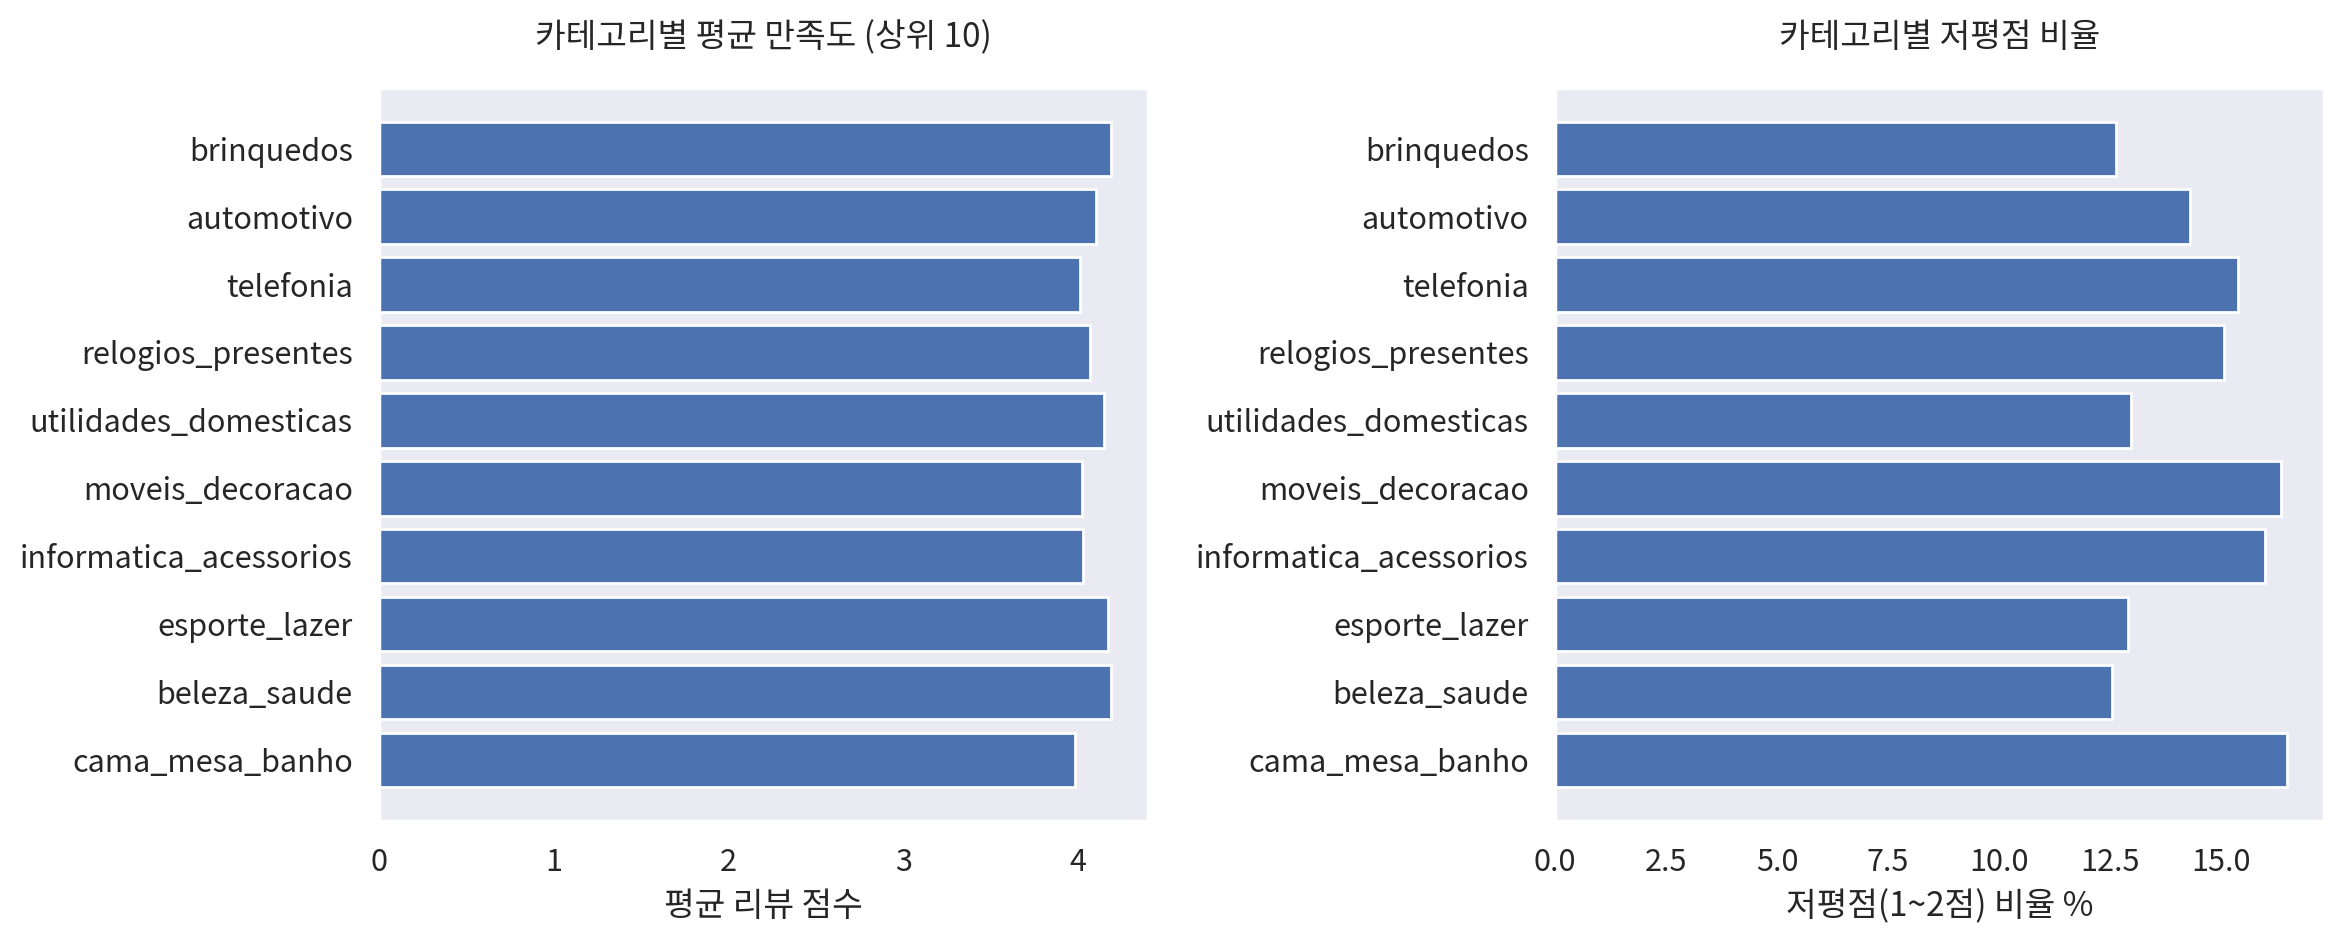

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_cat = cat_summary.head(10)
axes[0].barh(top_cat.index, top_cat["평균_점수"])
axes[0].set_xlabel("평균 리뷰 점수")
axes[0].set_title("카테고리별 평균 만족도 (상위 10)")
axes[1].barh(top_cat.index, top_cat["저평점_비율"])
axes[1].set_xlabel("저평점(1~2점) 비율 %")
axes[1].set_title("카테고리별 저평점 비율")
plt.tight_layout()
plt.show()

## 3. 가격 구간별 만족도

In [4]:
rev["price_bin"] = pd.cut(rev["price"], bins=[0, 50, 150, 500, 10000], labels=["저가", "중저가", "중고가", "고가"])
price_summary = rev.groupby("price_bin", observed=True).agg(
    리뷰수=("review_score", "count"),
    평균_점수=("review_score", "mean"),
    저평점_비율=("review_score", lambda x: (x <= 2).mean() * 100),
).round(2)
print(price_summary)

             리뷰수  평균_점수  저평점_비율
price_bin                      
저가         32581  4.120  13.690
중저가        44680  4.110  14.060
중고가        17602  4.090  14.790
고가          3054  4.030  17.550


## 4. NPS 스타일 (추천자 - 비추천자)

In [5]:
# NPS: 9~10점 추천, 0~6 비추천, 7~8 수동적 (5점 척도이므로 5=추천, 1~2=비추천, 3~4=수동적)
rev["nps_group"] = pd.cut(rev["review_score"], bins=[0, 2, 4, 5], labels=["비추천", "수동적", "추천"])
nps_counts = rev["nps_group"].value_counts(normalize=True) * 100
nps_score = nps_counts.get("추천", 0) - nps_counts.get("비추천", 0)
print("NPS 그룹 비율(%):", nps_counts.to_dict())
print("NPS 스타일 점수 (추천% - 비추천%):", round(nps_score, 1))

NPS 그룹 비율(%): {'추천': 57.78581780223567, '수동적': 27.53336779058101, '비추천': 14.680814407183323}
NPS 스타일 점수 (추천% - 비추천%): 43.1
